In [15]:
# imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import LinearRegression

Load the UCI ML Repository's Heart Disease Dataset. I have saved a csv version to the url below.

In [16]:
# Load the heart disease CSV file into a DataFrame
df_heart_disease = pd.read_csv('https://raw.githubusercontent.com/benjaminmlucas/MAT499/refs/heads/main/module_1/heart_disease.csv')

# Display the first 5 rows of the DataFrame
display(df_heart_disease)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3,0
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3,0
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3,0
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3,0


We are going to reduce the dataset to 6 observations for the first couple of examples. The following code block will select the appropriate rows and the subsequent block will plot the data.

In [17]:
rows_to_keep = [4, 40, 86, 175, 183, 189]
df_heart_disease_subset = df_heart_disease.loc[rows_to_keep]
display(df_heart_disease_subset)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1
40,51,0,2,140,308,0,0,142,0,1.5,2,1,2,1
86,68,1,2,118,277,0,1,151,0,1.0,2,1,3,1
175,40,1,0,110,167,0,0,114,1,2.0,1,0,3,0
183,58,1,2,112,230,0,0,165,0,2.5,1,1,3,0
189,41,1,0,110,172,0,0,158,0,0.0,2,0,3,0


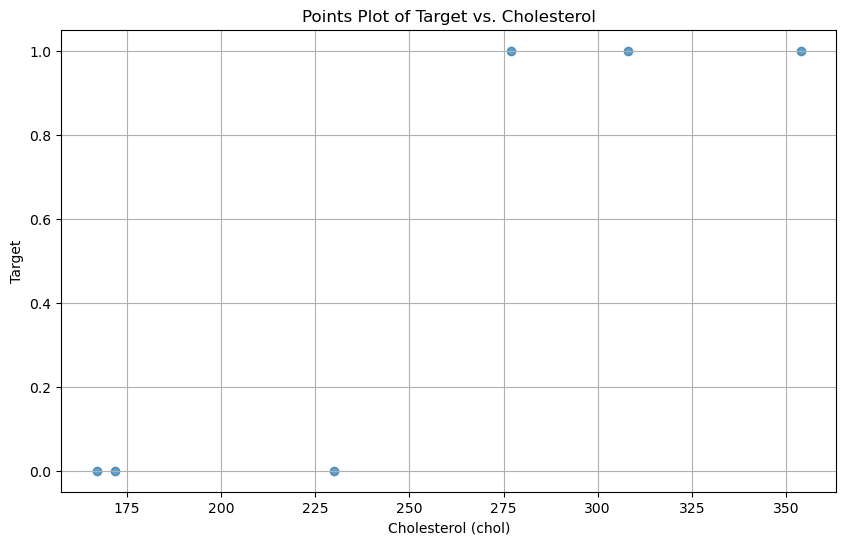

In [18]:
plt.figure(figsize=(10, 6))
plt.scatter(df_heart_disease_subset['chol'], df_heart_disease_subset['target'], alpha=0.7)
plt.title('Points Plot of Target vs. Cholesterol')
plt.xlabel('Cholesterol (chol)')
plt.ylabel('Target')
plt.grid(True)
plt.show()

If this were a regression problem we could fit a Linear Regression model to the data... as shown below. (Note this isn't a good idea as we'll see below).

Coefficient for 'chol': 0.0065
Intercept: -1.1447


/Users/itzjuztmya/miniconda3/envs/school/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


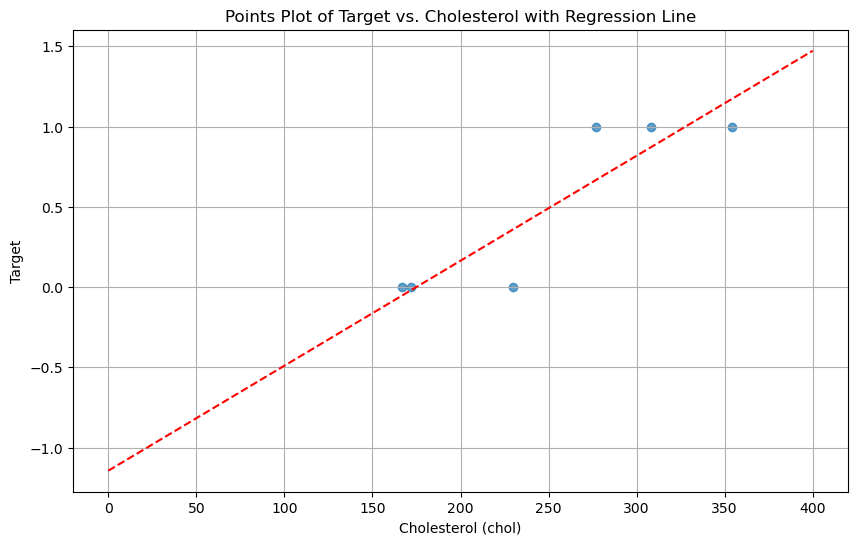

In [19]:
# Define the predictor variable (X) and target variable (y)
X = df_heart_disease_subset[['chol']]
y = df_heart_disease_subset['target']

# Create a linear regression model
model = LinearRegression()

# Fit the model to the data
model.fit(X, y)

# Print the coefficients and intercept
print(f"Coefficient for 'chol': {model.coef_[0]:.4f}")
print(f"Intercept: {model.intercept_:.4f}")

# Recreate the scatter plot using df_heart_disease_subset
plt.figure(figsize=(10, 6))
plt.scatter(df_heart_disease_subset['chol'], df_heart_disease_subset['target'], alpha=0.7, label='Data Points (Subset)')

# Generate x-values for the regression line, covering the range of 'chol' in the subset
x_line = np.linspace(0, 400, 400).reshape(-1, 1)

# Predict y-values using the trained model (model was trained on the full df_heart_disease)
y_line = model.predict(x_line)

# Plot the regression line
plt.plot(x_line, y_line, color='red', linestyle='--', label='Linear Regression Line')

plt.title('Points Plot of Target vs. Cholesterol with Regression Line')
plt.xlabel('Cholesterol (chol)')
plt.ylabel('Target')
plt.grid(True)
# plt.legend()
plt.show()

If we fit a linear model as above, it's possible to get predictions outside of our two possibilities (0 or 1). For this reason we need to use Logistic Regression. In Logistic Regression, we apply the sigmoid function to a standard linear model to transform the output to a value that is between 0 and 1. This value then represents the probability that the target=1. The following code block fits a logistic regression and the subsequent one plots the fitted curve to the data.

In [20]:
# Define the predictor variable (X) and target variable (y) from the subset
X_log = df_heart_disease_subset[['chol']]
y_log = df_heart_disease_subset['target']

# Create a logistic regression model
logistic_model = LogisticRegression()

# Fit the model to the data
logistic_model.fit(X_log, y_log)

# Print the coefficients and intercept
print(f"Coefficient for 'chol': {logistic_model.coef_[0][0]:.4f}")
print(f"Intercept: {logistic_model.intercept_[0]:.4f}")

Coefficient for 'chol': 0.2268
Intercept: -57.4975


/Users/itzjuztmya/miniconda3/envs/school/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


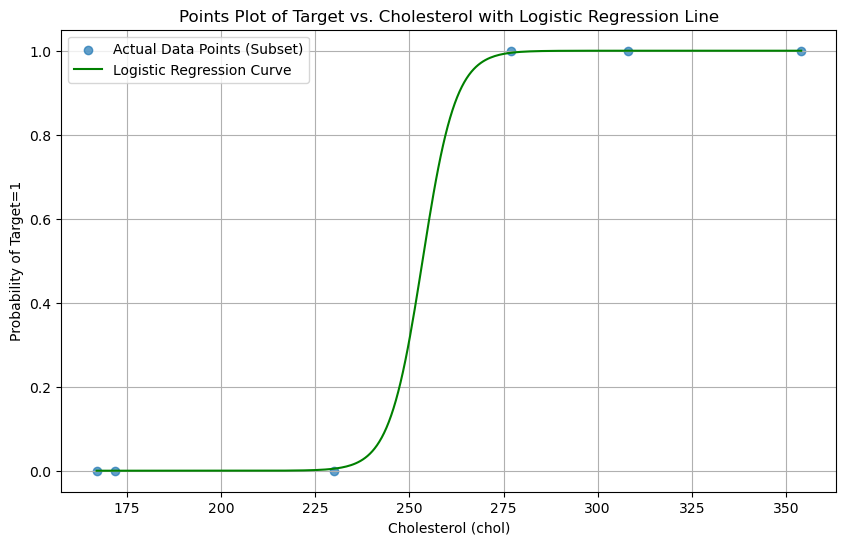

In [21]:
# Create a scatter plot of the actual data points from the subset
plt.figure(figsize=(10, 6))
plt.scatter(df_heart_disease_subset['chol'], df_heart_disease_subset['target'], alpha=0.7, label='Actual Data Points (Subset)')

# Generate a range of 'chol' values for plotting the logistic regression curve
x_plot = np.linspace(df_heart_disease_subset['chol'].min(), df_heart_disease_subset['chol'].max(), 300).reshape(-1, 1)

# Predict probabilities using the fitted logistic regression model
y_proba = logistic_model.predict_proba(x_plot)[:, 1]  # Get probability of target=1

# Plot the logistic regression curve
plt.plot(x_plot, y_proba, color='green', linestyle='-', label='Logistic Regression Curve')

plt.title('Points Plot of Target vs. Cholesterol with Logistic Regression Line')
plt.xlabel('Cholesterol (chol)')
plt.ylabel('Probability of Target=1')
plt.grid(True)
plt.legend()
plt.show()

Now we want to extend the example - we will use all the instances but still subset the predictors (we'll use 3 total). The first code block subsets the data and the second scales the data. We usually scale the data for neural networks to help gradient descent converge quicker, to prevent any numerical instability, and prevent one predictor from dominating the learning process if it's on a different scale.

In [22]:
# Define the predictor variables (X) and target variable (y) from the subset
X_multiple_log_regression = df_heart_disease[['chol', 'age', 'trestbps']]
y = df_heart_disease['target']

In [23]:
# here I'm going to standardize the data
from sklearn.preprocessing import StandardScaler

# Initialize the StandardScaler
scaler = StandardScaler()

# Fit the scaler to the data and transform it
X_multiple_log_regression_scaled = scaler.fit_transform(X_multiple_log_regression)

# Convert the scaled array back to a DataFrame for easier viewing
X_multiple_log_regression_scaled = pd.DataFrame(X_multiple_log_regression_scaled, columns=X_multiple_log_regression.columns)

# Display the first few rows of the scaled DataFrame
display(X_multiple_log_regression_scaled)

,chol,age,trestbps
0,-0.256334,0.952197,0.763956
1,0.072199,-1.915313,-0.092738
2,-0.816773,-1.474158,-0.092738
3,-0.198357,0.180175,-0.663867
4,2.082050,0.290464,-0.663867
...,...,...,...
298,-0.101730,0.290464,0.478391
299,0.342756,-1.033002,-1.234996
300,-1.029353,1.503641,0.706843
301,-2.227533,0.290464,-0.092738


Now we are going to fit a Logistic Regession model using PyTorch and learn the values of the parameters with Gradient Descent.

In [24]:
# define a logistic regression model in pytorch
import torch
import torch.nn as nn
import torch.optim as optim



class LogisticRegressionModel(nn.Module):
    # these are the components of the model. We need a linear model and a sigmoid function.
    def __init__(self, input_dim):
        super(LogisticRegressionModel, self).__init__()
        # this will create a linear model of our 3 input features and output 1 value (the prediction)
        self.linear = nn.Linear(input_dim, 1)
        self.sigmoid = nn.Sigmoid()

    # This is a method that all torch models must have.
    # It will always have these 2 parameters (self, x) so the header will always look the same as this.
    def forward(self, x):
        Z = self.linear(x)
        Y_hat = self.sigmoid(Z)
        return Y_hat

In [25]:
# Now let's fit this model to our data

# To use PyTorch you must convert our data to PyTorch tensors
X_torch = torch.tensor(X_multiple_log_regression_scaled.values, dtype=torch.float32)
y_torch = torch.tensor(y.values, dtype=torch.float32).view(-1, 1)

# Notes about the above:
# .view(-1, 1) means:
# -1: "Infer the number of rows based on the data length"
#  1: "Force exactly 1 column"
# all data must be floats to calculate gradients

# Initialize the model we defined above
model = LogisticRegressionModel(3)

# Print the random initial values of the weights and bias
with torch.no_grad():
    print(f'Initial Values: Weights = {model.linear.weight.numpy()[0].round(decimals=3)}, \
Bias = {model.linear.bias.numpy().round(decimals=3)}')

# Define our Loss function and algorithm for optimization (aka our 'Optimizer')
# BCELoss = Binary Cross Entropy Loss (standard for binary classification)
criterion = nn.BCELoss()

# This is the function for 'Stocastic' Gradient Descent not plain Gradient Descent as we have discussed,
# BUT the below does not add any of the stochastic elements (randomness) so it will act exactly as we have seen.
optimizer = optim.SGD(model.parameters(), lr=0.05)


# The following is the training loop, the number of 'epochs' is the number of times
# we want our whole dataset to propagate forward through the model. In this example that will
# also equal the number of steps of gradient descent we will make.

epochs = 1_000

print()
print("Starting Training with Gradient Descent...")
print()
for epoch in range(epochs):

    # We pass the entire dataset X at once to the model and calculate predictions
    y_pred = model(X_torch)

    # note here we actually calculate the cost not the loss but all PyTorch syntax calls this the loss
    loss = criterion(y_pred, y_torch)

    # these steps (1) delete any previous gradient calculations, (2) do backpropagation and (3) update the model parameters
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if (epoch + 1) % 10 == 0:
      # the below line prevents Torch from remembering the following,
      # it's fine if you forget it, but everything will be slower with larger datasets
      with torch.no_grad():
          predicted_labels = (y_pred > 0.5).float()
          accuracy = (predicted_labels == y_torch).float().mean()
          print(f'Epoch {epoch+1}: Loss = {loss.item():.5f}, Accuracy = {accuracy.item():.2f}')
print()
print('Training Complete.')
print()
# Print the final learned values of the weights and bias
with torch.no_grad():
    print(f'Final Trained Values: Weights = {model.linear.weight.numpy()[0].round(decimals=3)}, \
    Bias = {model.linear.bias.numpy().round(decimals=3)}')


Initial Values: Weights = [ 0.431 -0.568 -0.294], Bias = [0.374]

Starting Training with Gradient Descent...

Epoch 10: Loss = 0.68593, Accuracy = 0.57
Epoch 20: Loss = 0.68124, Accuracy = 0.57
Epoch 30: Loss = 0.67731, Accuracy = 0.58
Epoch 40: Loss = 0.67403, Accuracy = 0.58
Epoch 50: Loss = 0.67132, Accuracy = 0.59
Epoch 60: Loss = 0.66908, Accuracy = 0.59
Epoch 70: Loss = 0.66723, Accuracy = 0.60
Epoch 80: Loss = 0.66571, Accuracy = 0.60
Epoch 90: Loss = 0.66446, Accuracy = 0.60
Epoch 100: Loss = 0.66344, Accuracy = 0.60
Epoch 110: Loss = 0.66261, Accuracy = 0.59
Epoch 120: Loss = 0.66192, Accuracy = 0.59
Epoch 130: Loss = 0.66136, Accuracy = 0.60
Epoch 140: Loss = 0.66091, Accuracy = 0.61
Epoch 150: Loss = 0.66053, Accuracy = 0.61
Epoch 160: Loss = 0.66023, Accuracy = 0.61
Epoch 170: Loss = 0.65998, Accuracy = 0.61
Epoch 180: Loss = 0.65977, Accuracy = 0.61
Epoch 190: Loss = 0.65960, Accuracy = 0.61
Epoch 200: Loss = 0.65947, Accuracy = 0.61
Epoch 210: Loss = 0.65935, Accuracy = 0

Just to check our results, let's fit a logistic regression the 'usual' way.

In [26]:
# Create a logistic regression model
multiple_logistic_model = LogisticRegression(solver='liblinear') # 'liblinear' is a good choice for small datasets

# Fit the model to the data
multiple_logistic_model.fit(X_multiple_log_regression_scaled, y)

# Print the model parameters
print(f'Weights: {multiple_logistic_model.coef_[0].round(3)}, Bias: {multiple_logistic_model.intercept_[0]:.3f}')

Weights: [-0.071 -0.405 -0.18 ], Bias: 0.188
